<a href="https://colab.research.google.com/github/harshakurada/Retail-Demand-Forecasting-ML-system/blob/main/DF_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

In [7]:
from google.colab import files
uploaded = files.upload()

Saving archive (7).zip to archive (7).zip


In [8]:
import pandas as pd

df = pd.read_csv("archive (7).zip")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [9]:
import os

os.listdir()

['.config', '.ipynb_checkpoints', 'archive (7).zip', 'sample_data']

In [11]:
import zipfile

zip_path = "archive (7).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")
    import os

os.listdir("data")

['bigmart.csv']

In [12]:
import pandas as pd

df = pd.read_csv("data/bigmart.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [13]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [14]:
# Missing values check
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [15]:
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

In [16]:
fig = px.histogram(
    df,
    x="Item_Outlet_Sales",
    nbins=50,
    title="📦 Sales Distribution"
)

fig.show()

In [17]:
fig = px.histogram(
    np.log1p(df["Item_Outlet_Sales"]),
    nbins=50,
    title="📊 Log Transformed Sales Distribution"
)

fig.show()

In [18]:
outlet_sales = df.groupby("Outlet_Type")["Item_Outlet_Sales"].mean().reset_index()

fig = px.bar(
    outlet_sales,
    x="Outlet_Type",
    y="Item_Outlet_Sales",
    title="🏪 Outlet Type vs Average Sales"
)

fig.show()

In [19]:
loc_sales = df.groupby("Outlet_Location_Type")["Item_Outlet_Sales"].mean().reset_index()

fig = px.bar(
    loc_sales,
    x="Outlet_Location_Type",
    y="Item_Outlet_Sales",
    title="📍 Location Type vs Sales"
)

fig.show()

In [20]:
df['Outlet_Years'] = 2026 - df['Outlet_Establishment_Year']

fig = px.scatter(
    df,
    x="Outlet_Years",
    y="Item_Outlet_Sales",
    title="🏗️ Outlet Age vs Sales"
)

fig.show()

In [21]:
item_sales = df.groupby("Item_Type")["Item_Outlet_Sales"].mean().sort_values(ascending=False)

fig = px.bar(
    item_sales,
    x=item_sales.index,
    y=item_sales.values,
    title="🍎 Item Type vs Sales"
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [23]:
fat_sales = df.groupby("Item_Fat_Content")["Item_Outlet_Sales"].mean().reset_index()

fig = px.bar(
    fat_sales,
    x="Item_Fat_Content",
    y="Item_Outlet_Sales",
    title="⚖️ Fat Content vs Sales"
)

fig.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.



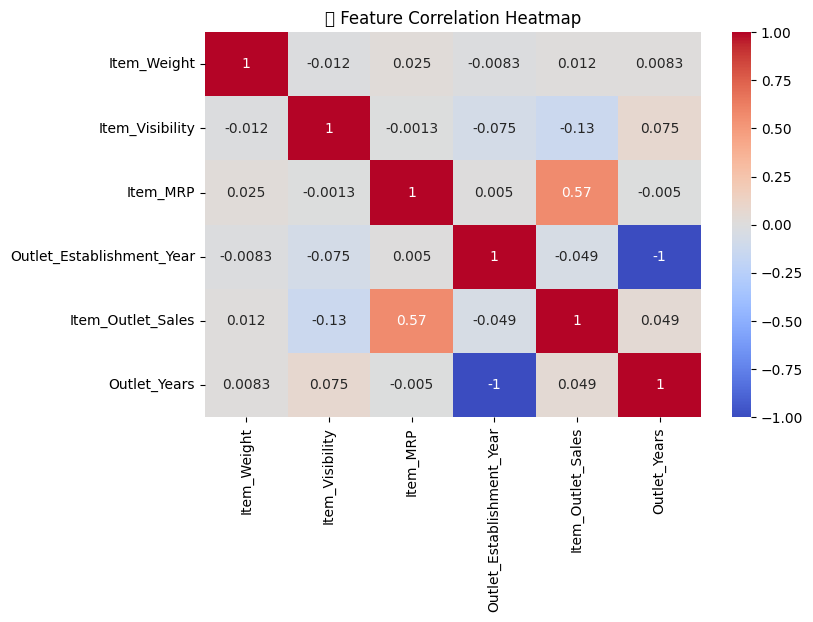

In [24]:
plt.figure(figsize=(8,5))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("🔗 Feature Correlation Heatmap")
plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder

cat_cols = [
    'Item_Fat_Content',
    'Item_Type',
    'Outlet_Identifier',
    'Outlet_Size',
    'Outlet_Location_Type',
    'Outlet_Type'
]

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [26]:
X = df.drop("Item_Outlet_Sales", axis=1)
y = df["Item_Outlet_Sales"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [33]:
df = df.drop(columns=["Item_Identifier"], errors="ignore")

In [34]:
df.columns

Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type',
       'Item_Outlet_Sales', 'Outlet_Years'],
      dtype='object')

In [35]:
df_encoded = pd.get_dummies(df)

In [36]:
X = df_encoded.drop("Item_Outlet_Sales", axis=1)
y = df_encoded["Item_Outlet_Sales"]

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    results.append([name, rmse, mae])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000644 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 801
[LightGBM] [Info] Number of data points in the train set: 6818, number of used features: 11
[LightGBM] [Info] Start training from score 2202.365232


In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae
    })

results_df = pd.DataFrame(results)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000307 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 801
[LightGBM] [Info] Number of data points in the train set: 6818, number of used features: 11
[LightGBM] [Info] Start training from score 2202.365232


In [41]:
results_df = results_df.sort_values("RMSE")
results_df

,Model,RMSE,MAE
3,Gradient Boosting,1035.731451,721.673395
4,XGBoost,1061.307235,736.862035
5,LightGBM,1070.630442,745.803088
2,Random Forest,1082.057151,755.158822
0,Linear Regression,1136.365965,855.239994
1,Decision Tree,1513.380876,1048.487001


In [42]:
print("🏆 MODEL PERFORMANCE SUMMARY\n")
print(results_df.to_string(index=False))

🏆 MODEL PERFORMANCE SUMMARY

            Model        RMSE         MAE
Gradient Boosting 1035.731451  721.673395
          XGBoost 1061.307235  736.862035
         LightGBM 1070.630442  745.803088
    Random Forest 1082.057151  755.158822
Linear Regression 1136.365965  855.239994
    Decision Tree 1513.380876 1048.487001


In [43]:
import plotly.express as px

fig = px.bar(
    results_df,
    x="Model",
    y="RMSE",
    text="RMSE",
    title="📊 Model Comparison (Lower RMSE = Better)"
)

fig.show()

In [44]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [45]:
fig = px.bar(
    results_df,
    x="Model",
    y="MAE",
    text="MAE",
    title="📉 Model Comparison (MAE)"
)

fig.show()

In [55]:
with open("app.py", "w") as f:
    f.write("""
import streamlit as st
import joblib
import pandas as pd

st.title("Retail Demand Forecasting App")

st.write("App is running successfully 🚀")
""")
    import os
os.listdir()

['.config',
 '.ipynb_checkpoints',
 'app.py',
 'archive (7).zip',
 'data',
 'sample_data']

In [56]:
from google.colab import files

files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
import joblib


joblib.dump(model, "best_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [61]:
from google.colab import files

files.download("best_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
from google.colab import files
files.upload()

Saving archive (8).zip to archive (8) (1).zip


{'archive (8) (1).zip': b'PK\x03\x04-\x00\x00\x00\x08\x00qQ:OW\xd6\xd3`\xff\xff\xff\xff\xff\xff\xff\xff\x08\x00\x14\x00Test.csv\x01\x00\x10\x00]\r\x08\x00\x00\x00\x00\x00\xa5\xa4\x01\x00\x00\x00\x00\x00\xac\xbd\xd9\xae#I\x92$\xfa~\x81\xfb\x0f\xf5\x01\x07\x84\xed\xcbc\x04\x19\'vF\x04O\xec/\x8d\x9c\xee\xa8\xeeDgW\x0e\xb2\xb21\xe8\xf9\xfa+bNw\xba\x1a\xe9yL\x03w6\xf4Te\xfaq\x9a\xab\xa9\x8a\xaa\x8a\x8a\xbe\xfc\xf3\xc7\x7f\xfd\xcb\xcb\x7f\xfb\xf1\x8f?\x7f\xfd\xfb\xaf?\xfe\xb8k\xff\xff/?~\xfd\xf7\xff\xf8s\xfa\x9f\xef\x7f\xf9\xf3_\xf6\xbf\xff\xe3O\xfc\x13\xd3\x7f\xf0\xf9\xd7\x7f\xfe\xfa\xbf~\xfd\xed\xd7?\xffg\xfa\xff\x7f\xfc\x9f\xff\xfdc\xfa\x9f\xde\x9e\xde\xdf\xbd\xfb\xef?\x7f\xfb\xf1\xe7\xfa\x89\xe7\xff\xe4\xd9?\xff\xfc\xe5\x7f\xfd\xf6\xeb?\xff\xe3\xbf\xf0\xdf\xfc\xcb\xb7\x1f\xbf,\xff\xcd\xc3\xaf\xff\xf7\xc7\xfc?\xbf\xf9\xfd_\x7f\xf9\xf3\xd7\xdf\xff1=\xf5\xfc\x1f\xf2\x7f\xfe\x7f\xff\x9f\xfb\xc3\x97X\xee\x9c\xd9\xe5x\xf7\xe6\xf7\xff\xf37\xbc\xd8\x9d\xd9\x19\x93c\n\xc5\xa7\xbb\x87\x7f\xfc\xf2\

In [67]:
import zipfile

with zipfile.ZipFile("archive (8).zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [65]:
from google.colab import files
files.upload()

Saving archive (8).zip to archive (8).zip


{'archive (8).zip': b'PK\x03\x04-\x00\x00\x00\x08\x00qQ:OW\xd6\xd3`\xff\xff\xff\xff\xff\xff\xff\xff\x08\x00\x14\x00Test.csv\x01\x00\x10\x00]\r\x08\x00\x00\x00\x00\x00\xa5\xa4\x01\x00\x00\x00\x00\x00\xac\xbd\xd9\xae#I\x92$\xfa~\x81\xfb\x0f\xf5\x01\x07\x84\xed\xcbc\x04\x19\'vF\x04O\xec/\x8d\x9c\xee\xa8\xeeDgW\x0e\xb2\xb21\xe8\xf9\xfa+bNw\xba\x1a\xe9yL\x03w6\xf4Te\xfaq\x9a\xab\xa9\x8a\xaa\x8a\x8a\xbe\xfc\xf3\xc7\x7f\xfd\xcb\xcb\x7f\xfb\xf1\x8f?\x7f\xfd\xfb\xaf?\xfe\xb8k\xff\xff/?~\xfd\xf7\xff\xf8s\xfa\x9f\xef\x7f\xf9\xf3_\xf6\xbf\xff\xe3O\xfc\x13\xd3\x7f\xf0\xf9\xd7\x7f\xfe\xfa\xbf~\xfd\xed\xd7?\xffg\xfa\xff\x7f\xfc\x9f\xff\xfdc\xfa\x9f\xde\x9e\xde\xdf\xbd\xfb\xef?\x7f\xfb\xf1\xe7\xfa\x89\xe7\xff\xe4\xd9?\xff\xfc\xe5\x7f\xfd\xf6\xeb?\xff\xe3\xbf\xf0\xdf\xfc\xcb\xb7\x1f\xbf,\xff\xcd\xc3\xaf\xff\xf7\xc7\xfc?\xbf\xf9\xfd_\x7f\xf9\xf3\xd7\xdf\xff1=\xf5\xfc\x1f\xf2\x7f\xfe\x7f\xff\x9f\xfb\xc3\x97X\xee\x9c\xd9\xe5x\xf7\xe6\xf7\xff\xf37\xbc\xd8\x9d\xd9\x19\x93c\n\xc5\xa7\xbb\x87\x7f\xfc\xf2\xaf\

In [68]:
import os

os.listdir("data")

['Test.csv', 'bigmart.csv', 'Train.csv']

In [69]:
import pandas as pd

df = pd.read_csv("data/Train.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [70]:
import zipfile

with zipfile.ZipFile("archive (8).zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [71]:
import os

for root, dirs, files in os.walk("data"):
    for f in files:
        if "train" in f.lower():
            print(root + "/" + f)

data/Train.csv


In [72]:
import shutil

shutil.copy("data/Train.csv", "Train.csv")

'Train.csv'

In [73]:
from google.colab import files

files.download("Train.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>